In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import (
    train_test_split,
    cross_val_score,
    StratifiedKFold,
    GridSearchCV
)

from sklearn.preprocessing import StandardScaler

from sklearn.impute import SimpleImputer

from sklearn.pipeline import make_pipeline

from sklearn.tree import DecisionTreeClassifier

from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier
)

from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    roc_auc_score,
    roc_curve
)

In [15]:
df = pd.read_csv("data/insurance.csv")

df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [16]:
X = df.drop("charges", axis=1)

y = (df["charges"] > df["charges"].median()).astype(int)

In [17]:
X = pd.get_dummies(X, drop_first=True)

print(X.head())

   age     bmi  children  sex_male  smoker_yes  region_northwest  \
0   19  27.900         0     False        True             False   
1   18  33.770         1      True       False             False   
2   28  33.000         3      True       False             False   
3   33  22.705         0      True       False              True   
4   32  28.880         0      True       False              True   

   region_southeast  region_southwest  
0             False              True  
1              True             False  
2              True             False  
3             False             False  
4             False             False  


In [18]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [19]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

In [20]:
dt_default = DecisionTreeClassifier(random_state=42)

dt_default.fit(X_train_scaled, y_train)

train_acc_default = accuracy_score(
    y_train,
    dt_default.predict(X_train_scaled)
)

test_acc_default = accuracy_score(
    y_test,
    dt_default.predict(X_test_scaled)
)

print("Training Accuracy:", train_acc_default)
print("Testing Accuracy :", test_acc_default)

Training Accuracy: 0.9981308411214953
Testing Accuracy : 0.8768656716417911


In [21]:
dt_control = DecisionTreeClassifier(
    max_depth=5,
    min_samples_split=20,
    random_state=42
)

dt_control.fit(X_train_scaled, y_train)

train_acc_control = accuracy_score(
    y_train,
    dt_control.predict(X_train_scaled)
)

test_acc_control = accuracy_score(
    y_test,
    dt_control.predict(X_test_scaled)
)

print("Training Accuracy:", train_acc_control)
print("Testing Accuracy :", test_acc_control)

Training Accuracy: 0.9317757009345794
Testing Accuracy : 0.9328358208955224


In [22]:
tree_gini = DecisionTreeClassifier(
    criterion="gini",
    max_depth=5,
    random_state=42
)

tree_gini.fit(X_train_scaled, y_train)

gini_acc = accuracy_score(
    y_test,
    tree_gini.predict(X_test_scaled)
)

print("Gini Accuracy:", gini_acc)

Gini Accuracy: 0.9328358208955224


In [23]:
tree_entropy = DecisionTreeClassifier(
    criterion="entropy",
    max_depth=5,
    random_state=42
)

tree_entropy.fit(X_train_scaled, y_train)

entropy_acc = accuracy_score(
    y_test,
    tree_entropy.predict(X_test_scaled)
)

print("Entropy Accuracy:", entropy_acc)

Entropy Accuracy: 0.9216417910447762


In [24]:
rf = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    random_state=42
)

rf.fit(X_train_scaled, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y

In [25]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

print(importance.head(5))

      Feature  Importance
0         age    0.509649
4  smoker_yes    0.307541
1         bmi    0.107409
2    children    0.040811
3    sex_male    0.012968


In [26]:
rf_train = accuracy_score(
    y_train,
    rf.predict(X_train_scaled)
)

rf_test = accuracy_score(
    y_test,
    rf.predict(X_test_scaled)
)

rf_auc = roc_auc_score(
    y_test,
    rf.predict_proba(X_test_scaled)[:,1]
)

print("Training Accuracy:", rf_train)
print("Testing Accuracy :", rf_test)
print("ROC AUC:", rf_auc)

Training Accuracy: 0.9616822429906542
Testing Accuracy : 0.9402985074626866
ROC AUC: 0.9600830900516505


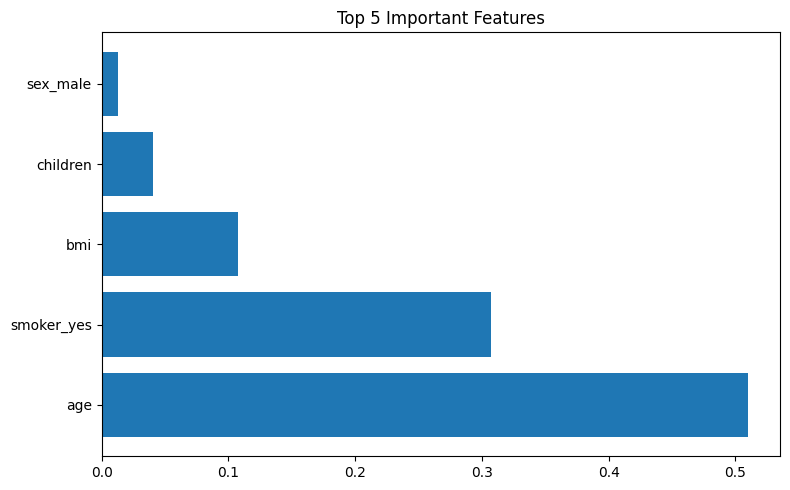

In [27]:
top5 = importance.head(5)

plt.figure(figsize=(8,5))

plt.barh(
    top5["Feature"],
    top5["Importance"]
)

plt.title("Top 5 Important Features")

plt.tight_layout()

plt.savefig("plots/top5_features.png")

plt.show()

In [28]:
gb = GradientBoostingClassifier(
    n_estimators=100,
    learning_rate=0.1,
    random_state=42
)

gb.fit(X_train_scaled, y_train)

,"loss loss: {'log_loss', 'exponential'}, default='log_loss'The loss function to be optimized. 'log_loss' refers to binomial andmultinomial deviance, the same as used in logistic regression.It is a good choice for classification with probabilistic outputs.For loss 'exponential', gradient boosting recovers the AdaBoost algorithm.",'log_loss'
,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.For an example of the effects of this parameter and its interaction with``subsample``, see:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_regularization.py`.",0.1
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",100
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",1.0
,"criterion criterion: {'friedman_mse', 'squared_error'}, default='friedman_mse'The function to measure the quality of a split. Supported criteria are'friedman_mse' for the mean squared error with improvement score byFriedman, 'squared_error' for mean squared error. The default value of'friedman_mse' is generally the best as it can provide a betterapproximation in some cases... versionadded:: 0.18",'friedman_mse'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, values must be in the range `[2, inf)`.- If float, values must be in the range `(0.0, 1.0]` and `min_samples_split` will be `ceil(min_samples_split * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, values must be in the range `[1, inf)`.- If float, values must be in the range `(0.0, 1.0)` and `min_samples_leaf` will be `ceil(min_samples_leaf * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.Values must be in the range `[0.0, 0.5]`.",0.0
,"max_depth max_depth: int or None, default=3Maximum depth of the individual regression estimators. The maximumdepth limits the number of nodes in the tree. Tune this parameterfor best performance; the best value depends on the interactionof the input variables. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.If int, values must be in the range `[1, inf)`.",3
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.Values must be in the range `[0.0, inf)`.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, 

In [29]:
gb_train = accuracy_score(
    y_train,
    gb.predict(X_train_scaled)
)

gb_test = accuracy_score(
    y_test,
    gb.predict(X_test_scaled)
)

gb_auc = roc_auc_score(
    y_test,
    gb.predict_proba(X_test_scaled)[:,1]
)

print("Training Accuracy:", gb_train)
print("Testing Accuracy :", gb_test)
print("ROC AUC:", gb_auc)

Training Accuracy: 0.9514018691588785
Testing Accuracy : 0.9440298507462687
ROC AUC: 0.9662867729620481


In [30]:
lowest5 = importance.tail(5)

print(lowest5)

            Feature  Importance
2          children    0.040811
3          sex_male    0.012968
6  region_southeast    0.007820
7  region_southwest    0.007033
5  region_northwest    0.006769


In [31]:
remove_cols = lowest5["Feature"].tolist()

X_reduced = X.drop(columns=remove_cols)

In [32]:
X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(
    X_reduced,
    y,
    test_size=0.2,
    random_state=42
)

scaler_r = StandardScaler()

X_train_r = scaler_r.fit_transform(X_train_r)

X_test_r = scaler_r.transform(X_test_r)

In [33]:
rf_reduced = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    random_state=42
)

rf_reduced.fit(X_train_r,y_train_r)

auc_reduced = roc_auc_score(
    y_test_r,
    rf_reduced.predict_proba(X_test_r)[:,1]
)

print("Original RF AUC :", rf_auc)

print("Reduced RF AUC :", auc_reduced)

Original RF AUC : 0.9600830900516505
Reduced RF AUC : 0.9422299573321355
